In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

### Data
| Student | Study Hours | Attendance (%) | Assignment Score | Final Marks |
|------| ---|---|---|---|
| S1 | 2 | 60 | 45 | 48 | 
| S2 | 3 | 65 | 50 | 54 |
| S3 | 4 | 70 | 55 | 58 |
| S4 | 5 | 75 | 60 | 63 |
| S5 | 6 | 80 | 65 | 68 |
| S6 | 7 | 82 | 70 | 72 |
| S7 | 8 | 85 | 75 | 78 |
| S8 | 9 | 88 | 80 | 83 |
| S9 | 10 |  92|  85 | 89 |
| S10 | 20 | 98 | 95 | 97|

In [94]:
df = pd.DataFrame({
    "Study Hours": [2,3,4,5,6,7,8,9,10,20],
    "Attendance": [60,65,70,75,80,82,85,88,92,98],
    "Assignment Score": [45,50,55,60,65,70,75,80,85,95],
    "Final Marks": [48,54,58,63,68,72,78,83,89,97]
})

X = df[["Study Hours", "Attendance", "Assignment Score"]]
y = df["Final Marks"]

In [93]:
study_hours = torch.tensor([2,3,4,5,6,7,8,9,10,20], dtype=torch.float32)
attendance = torch.tensor([60, 65, 70, 75, 80, 82, 85, 88, 92, 98], dtype=torch.float32)
assignment_score = torch.tensor([45, 50, 55, 60, 65, 70, 75, 80, 85, 90], dtype=torch.float32)
final_marks = torch.tensor([48, 54, 58, 63, 68, 72, 78, 83, 89, 97], dtype=torch.float32)

study_hours, attendance, assignment_score, final_marks

(tensor([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 20.]),
 tensor([60., 65., 70., 75., 80., 82., 85., 88., 92., 98.]),
 tensor([45., 50., 55., 60., 65., 70., 75., 80., 85., 90.]),
 tensor([48., 54., 58., 63., 68., 72., 78., 83., 89., 97.]))

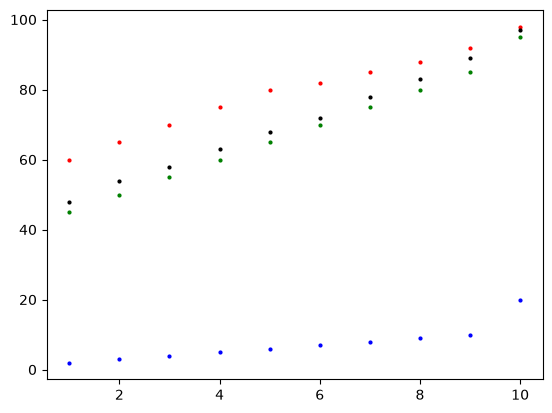

In [75]:
index = [i for i in range(1, 11)]
plt.scatter(index, df["Study Hours"], c="b", s=4)
plt.scatter(index, df["Attendance"], c="r", s=4)
plt.scatter(index, df["Assignment Score"], c="g", s=4)
plt.scatter(index, df["Final Marks"], c="black", s=4)

1) Find the **minimum**, **maximum**, **mean**, and **standard deviation** of the **Study Hours**
column and Identify whether any feature contains an outlier

In [79]:
print(f"minimum study hours = {study_hours.min()}")
print(f"maximum study hours = {study_hours.max()}")
print(f"mean study hours = {study_hours.mean()}")
print(f"standard deviation study hours = {study_hours.std()}")

print("\nBy using ScikitLearn's DataFrame")
print(f"minimum study hours = {df["Study Hours"].min()}")
print(f"maximum study hours = {df["Study Hours"].max()}")
print(f"mean study hours = {df["Study Hours"].mean()}")
print(f"standard deviation study hours = {df["Study Hours"].std()}")

minimum study hours = 2.0
maximum study hours = 20.0
mean study hours = 7.400000095367432
standard deviation study hours = 5.125101566314697

By using ScikitLearn's DataFrame
minimum study hours = 2
maximum study hours = 20
mean study hours = 7.4
standard deviation study hours = 5.125101625008686


finding the IQR, 

In [28]:
q = torch.quantile(study_hours, torch.tensor([0.25, 0.75]))
iqr = q[1] - q[0]
print(iqr)
lower = q[0] - 1.5 * iqr
upper = q[1] + 1.5 * iqr

tensor(4.5000)


removing the outliers

In [33]:
print(f"lower = {lower}, upper = {upper}")
new_study_hours = study_hours[(study_hours >= lower) & (study_hours <= upper)]
print(new_study_hours)

lower = -2.5, upper = 15.5
tensor([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])


2) Normalize the Study Hours column using Min-Max Normalization:  
X′=(X−X_min)/(X_max−X_min)  
Calculate the normalized value for every student to Verify that all values lie between 0 and 1.  
Use methods MinMaxScaler(): Initializes a Min-Max scaler.  
fit_transform(X[features]): Learns min and max values from data and scales features.  
X.copy(): Creates a copy to avoid modifying the original dataset

In [125]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
study_hours = df["Study Hours"].to_numpy().reshape(-1,1)

print(f"initial data (study hours): \n{study_hours}\n")
scaler.fit(study_hours)

print(f"data range = {scaler.data_range_}\nmin data point = {scaler.data_min_}\nmax data point = {scaler.data_max_}\nscale = {scaler.scale_}\nno of features = {scaler.n_features_in_}\nn samples seen = {scaler.n_samples_seen_}\n")

scaled_study_hours = scaler.transform(study_hours)
print(f"scaled_study_hours: \n{scaled_study_hours}")


initial data (study hours): 
[[ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [20]]

data range = [18.]
min data point = [2.]
max data point = [20.]
scale = [0.05555556]
no of features = 1
n samples seen = 10

scaled_study_hours: 
[[0.        ]
 [0.05555556]
 [0.11111111]
 [0.16666667]
 [0.22222222]
 [0.27777778]
 [0.33333333]
 [0.38888889]
 [0.44444444]
 [1.        ]]


3) Standardize the Study Hours column using: **z=(x−μ)/σ**  
Calculate the standardized value (z-score) for each student.  
Which students have positive z-scores and Which student is farthest from the mean?
Use methods StandardScaler(): Initializes a standard scaler.
fit_transform(X[features]): Computes mean and standard deviation, then standardizes
features.

In [135]:
from sklearn.preprocessing import StandardScaler

study_hours = df["Study Hours"].to_numpy().reshape(-1,1)
scaler = StandardScaler()
scaler.fit(study_hours)

print(f"scale = {scaler.scale_}\nscale squared = {scaler.scale_[0]*scaler.scale_[0]}\nmean = {scaler.mean_}\nvar = {scaler.var_}\nn features in = {scaler.n_features_in_}\nn samples seen = {scaler.n_samples_seen_}\n")
scaled_study_hours = scaler.transform(study_hours)
print(f"scaled study hours:\n{scaled_study_hours}")


scale = [4.86209831]
scale squared = 23.64
mean = [7.4]
var = [23.64]
n features in = 1
n samples seen = 10.0

scaled study hours:
[[-1.11063159]
 [-0.90495908]
 [-0.69928656]
 [-0.49361404]
 [-0.28794152]
 [-0.08226901]
 [ 0.12340351]
 [ 0.32907603]
 [ 0.53474855]
 [ 2.59147372]]


In [44]:
x = new_study_hours
print(f"minimum study hours = {x.min()}")
print(f"maximum study hours = {x.max()}")
print(f"mean study hours = {x.mean()}")
print(f"standard deviation study hours = {x.std()}")
print(f"x = {x}")
z = (x - x.mean())/x.std()
print(f"z = {z}")

minimum study hours = 2.0
maximum study hours = 10.0
mean study hours = 6.0
standard deviation study hours = 2.7386128902435303
x = tensor([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
z = tensor([-1.4606, -1.0954, -0.7303, -0.3651,  0.0000,  0.3651,  0.7303,  1.0954,
         1.4606])


| Day | Daily Sales (Units)|
|---|---|
| 1 | 2  |
| 2 | 3  |
| 3 | 4  |
| 4 | 5  |
| 5 | 7  |
| 6 | 10 |
| 7 | 15 |
| 8 | 22 |
| 9 | 35 |
| 10|  90|

4) Apply the **Box-Cox** Transform using **λ = 0.5**.  
Compute the transformed value for each observation. 
Compare the **Box-Cox** transformed values with the **Square Root** transformed
values.  
Which transformation reduces skewness more effectively?


[[-1.62377253]
 [-1.11987465]
 [-0.7886976 ]
 [-0.54589252]
 [-0.20162304]
 [ 0.13649189]
 [ 0.48992437]
 [ 0.79597731]
 [ 1.13398334]
 [ 1.72348343]]


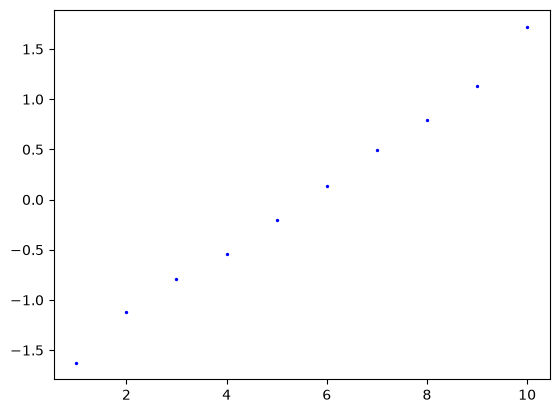

In [161]:
from sklearn.preprocessing import PowerTransformer

day = np.array([range(1,11)])
daily_sales = np.array([2,3,4,5,7,10,15,22,35,90]).reshape(-1,1)

scaler = PowerTransformer(method='box-cox')
scaler.fit(daily_sales)
print(scaler.transform(daily_sales))
plt.scatter(index, scaler.transform(daily_sales), c="b", s=2)

5) Apply the Function Transformers **Log Transform**, **Square Transform** and **Square Root
Transform**.  
Suggest which one works better with reason?
Analyse the transformed value for each observation. Compare the transformed values with the original values. Which values
changed the most after transformation?

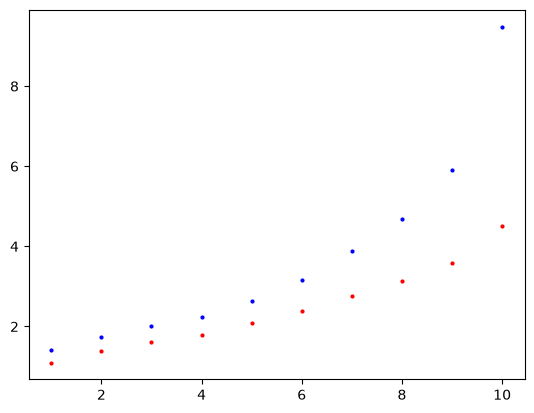

In [164]:
from sklearn.preprocessing import FunctionTransformer

log_transform = FunctionTransformer(np.log1p)
square_transform = FunctionTransformer(np.square)
sqrt_transform = FunctionTransformer(np.sqrt)


plt.scatter(day, log_transform.transform(daily_sales), c="r", s=4)
# plt.scatter(day, square_transform.transform(daily_sales), c="g", s=4)
plt.scatter(day, sqrt_transform.transform(daily_sales), c="b", s=4)

|Student| Test Score|
|---|---|
| S1 | 35|
| S2 | 42|
| S3 | 48|
| S4 | 53|
| S5 | 59|
| S6 | 64|
| S7 | 71|
| S8 | 78|
| S9 | 86|
| S10| 95|

6) Divide the scores into 4 equal-width bins:  
 Bin 1: 30–46 Grade D  
 Bin 2: 47–63 Grade C  
 Bin 3: 64–80 Grade B  
 Bin 4: 81–97 Grade A  
Assign each student to the correct bin. How many students fall into each bin?  
Replace each score with its bin number (1–4).  

In [182]:
from sklearn.preprocessing import FunctionTransformer

bins = [29, 46, 63, 80, 97, np.inf]
labels = ['D', 'C', 'B', 'A', 'A++']
transformer = FunctionTransformer(
    pd.cut, kw_args={'bins': bins, 'labels': labels, 'retbins': False}
)
x = np.array([35,42,48,53,59,64,71,78,86,95])
xt = transformer.transform(x)
print(xt)
for b in labels:
    print(f"grade {b}: {np.sum(b==xt)}")

# we can replace the lables?

['D', 'D', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'A']
Categories (5, str): ['D' < 'C' < 'B' < 'A' < 'A++']
grade D: 2
grade C: 3
grade B: 3
grade A: 2
grade A++: 0


7) Use the following threshold: Threshold = 60  
Rule: Score < 60 → 0 and Score ≥ 60 → 1  
Convert each score into a binary value.  
How many students receive a value of 1 and 0?  
Which students are classified as passing (1)?

In [179]:
from sklearn.preprocessing import FunctionTransformer

bins = [0, 59, np.inf]
labels = [0, 1]
transformer = FunctionTransformer(
    pd.cut, kw_args={'bins': bins, 'labels': labels, 'retbins': False}
)
xt = transformer.transform(x)
print(xt)

[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
Categories (2, int64): [0 < 1]


| Employee | Age |Monthly Salary (₹) |Department |
|---|---|---|---|
| E1 | 22  | 25000 | HR     |
| E2 | 25  | 28000 | Sales  |
| E3 | 27  | ?     | HR     |
| E4 | 29  | 35000 | IT     |
| E5 | 31  | 40000 | Sales  |
| E6 | 34  | ?     | IT     |
| E7 | 36  | 45000 | ?      |
| E8 | 39  | 50000 | Sales  |
| E9 | 42  | 55000 | IT     |
| E10|  45 |150000 | HR     |

In [183]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "Employee": ["E1","E2","E3","E4","E5","E6","E7","E8","E9","E10"],
    "Age": [22,25,27,29,31,34,36,39,42,45],
    "Salary": [25000,28000,np.nan,35000,40000,np.nan,45000,50000,55000,150000],
    "Department": ["HR","Sales","HR","IT","Sales","IT",np.nan,"Sales","IT","HR"]
})

print(df)

  Employee  Age    Salary Department
0       E1   22   25000.0         HR
1       E2   25   28000.0      Sales
2       E3   27       NaN         HR
3       E4   29   35000.0         IT
4       E5   31   40000.0      Sales
5       E6   34       NaN         IT
6       E7   36   45000.0        NaN
7       E8   39   50000.0      Sales
8       E9   42   55000.0         IT
9      E10   45  150000.0         HR


8) Remove all rows containing missing values. How many records remain after applying
Complete Case Analysis? Calculate the mean and median salary after removing incomplete
records.

In [188]:
clean = df.dropna()
print(clean)
print(f"remaining records = {len(clean)}\nmean salary = {clean["Salary"].mean()}\nmedian salary = {clean["Salary"].median()}\n")

  Employee  Age    Salary Department
0       E1   22   25000.0         HR
1       E2   25   28000.0      Sales
3       E4   29   35000.0         IT
4       E5   31   40000.0      Sales
7       E8   39   50000.0      Sales
8       E9   42   55000.0         IT
9      E10   45  150000.0         HR
remaining records = 7
mean salary = 54714.28571428572
median salary = 40000.0



9) Calculate the mean salary using only the available salary values. Replace each missing
salary with the calculated mean. Compute the new mean salary after imputation.

In [190]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')
df_mean = df.copy()
df_mean["Salary"] = mean_imputer.fit_transform(df[["Salary"]]).ravel()

print(df_mean)
print("New mean:", df_mean["Salary"].mean())


  Employee  Age    Salary Department
0       E1   22   25000.0         HR
1       E2   25   28000.0      Sales
2       E3   27   53500.0         HR
3       E4   29   35000.0         IT
4       E5   31   40000.0      Sales
5       E6   34   53500.0         IT
6       E7   36   45000.0        NaN
7       E8   39   50000.0      Sales
8       E9   42   55000.0         IT
9      E10   45  150000.0         HR
New mean: 53500.0


10) Calculate the median salary using the available salary values. Replace each missing
salary with the median. Compare the imputed values obtained using the mean and the
median.

In [191]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy='median')
df_median = df.copy()
df_median["Salary"] = median_imputer.fit_transform(df[["Salary"]]).ravel()

print(df_median)
print("New median:", df_median["Salary"].median())

  Employee  Age    Salary Department
0       E1   22   25000.0         HR
1       E2   25   28000.0      Sales
2       E3   27   42500.0         HR
3       E4   29   35000.0         IT
4       E5   31   40000.0      Sales
5       E6   34   42500.0         IT
6       E7   36   45000.0        NaN
7       E8   39   50000.0      Sales
8       E9   42   55000.0         IT
9      E10   45  150000.0         HR
New median: 42500.0


11) Determine the mode of the Department column. Replace the missing department with the
mode. How many employees belong to each department after imputation?

In [196]:
from sklearn.impute import SimpleImputer

mod_imputer = SimpleImputer(strategy='most_frequent')
df_mod = df.copy()
df_mod["Department"] = mod_imputer.fit_transform(df[["Department"]]).ravel()

print(df_mod)
print(df_mod["Department"].value_counts())

  Employee  Age    Salary Department
0       E1   22   25000.0         HR
1       E2   25   28000.0      Sales
2       E3   27       NaN         HR
3       E4   29   35000.0         IT
4       E5   31   40000.0      Sales
5       E6   34       NaN         IT
6       E7   36   45000.0         HR
7       E8   39   50000.0      Sales
8       E9   42   55000.0         IT
9      E10   45  150000.0         HR
Department
HR       4
Sales    3
IT       3
Name: count, dtype: int64
